<a href="https://colab.research.google.com/github/evanparisya/PCVK25_3F_09/blob/main/week5_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **D-1 PERCOBAAN HISTOGRAM **

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [37]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

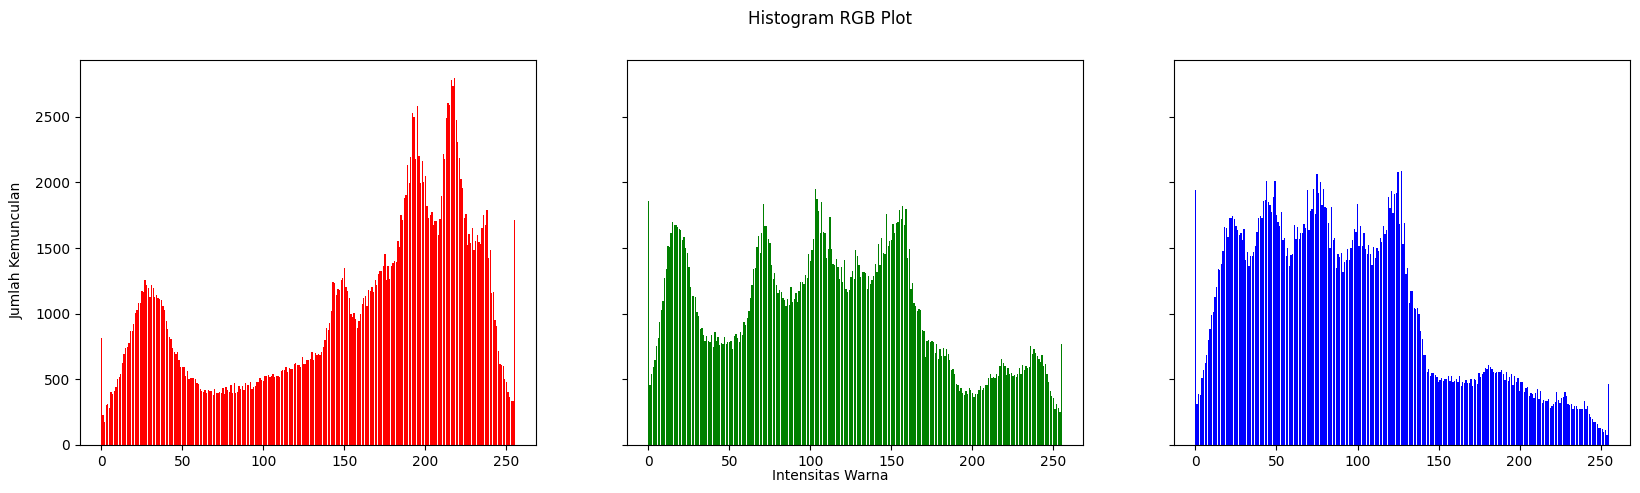

In [ ]:
# 3. Membuat histogram citra

img = cv.imread('/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_09/Image Jobsheet/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB Plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')


# PERTANYAAN PRAKTIKUM D1

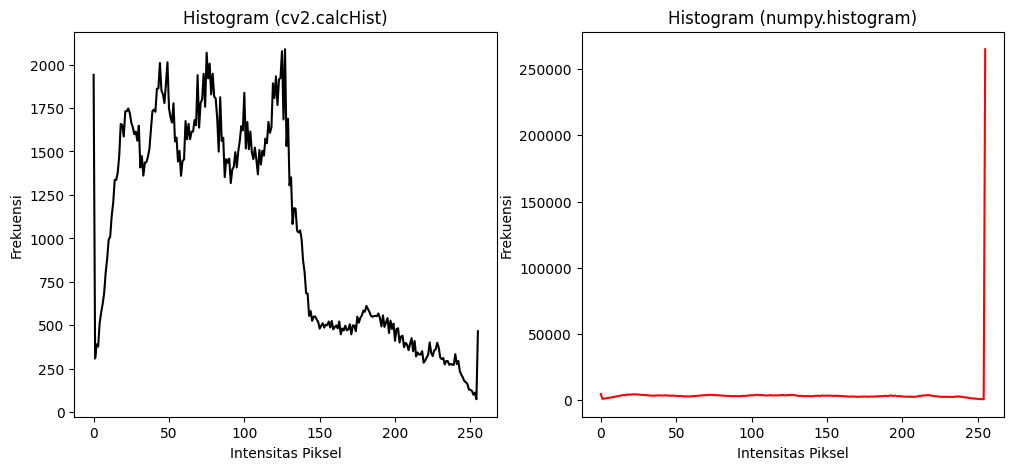

Ya, distribusi intensitas sama. Hanya format data yang berbeda


In [9]:
# 1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?
img = cv.imread('/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_09/Image Jobsheet/lena.jpg')
img = cv.cvtColor(img, cv.IMREAD_GRAYSCALE)

hist_cv2 = cv.calcHist([img], [0], None, [256], [0,256])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(hist_cv2, color='black')
plt.title("Histogram (cv2.calcHist)")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Frekuensi")

# Histogram dengan NumPy
hist_np, bins = np.histogram(img.ravel(), bins=256, range=[0,256])

plt.subplot(1,2,2)
plt.plot(hist_np, color='red')
plt.title("Histogram (numpy.histogram)")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Frekuensi")
plt.show()

print("Ya, distribusi intensitas sama. Hanya format data yang berbeda")

<BarContainer object of 256 artists>

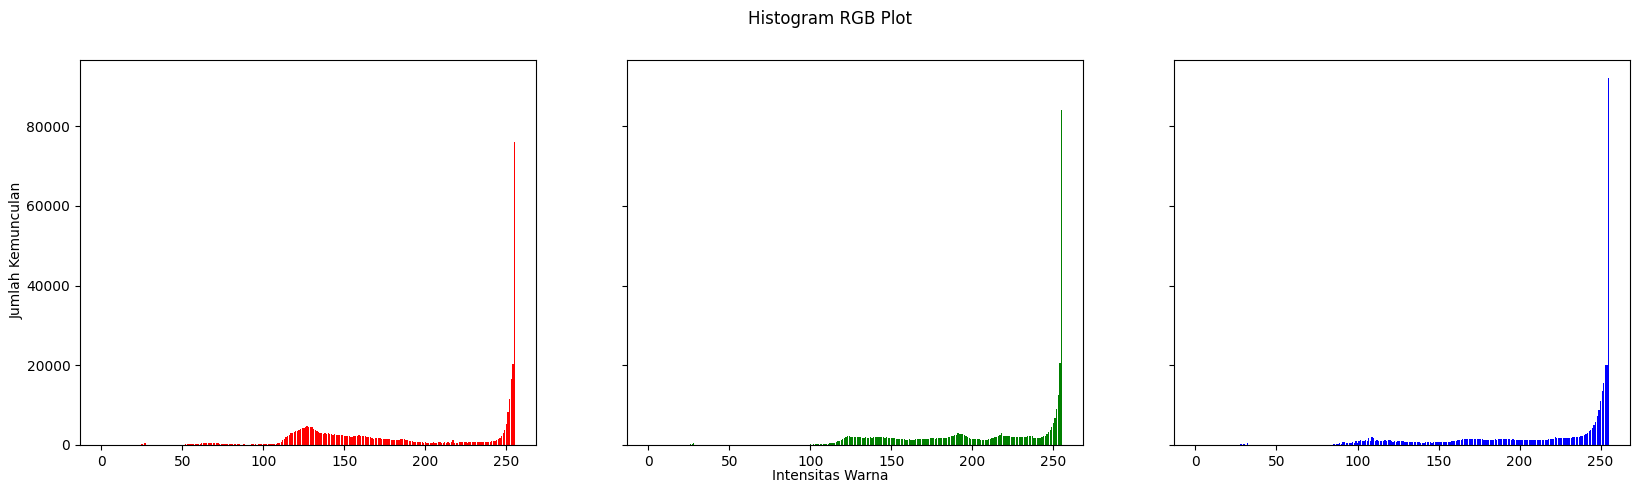

In [3]:
# 2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg. Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung gelap, terang, atau kontras rendah.
img = cv.imread('/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_09/Image Jobsheet/KTM lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB Plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')


# **D-2 PERCOBAAN HISTOGRAM EQUALIZATION**

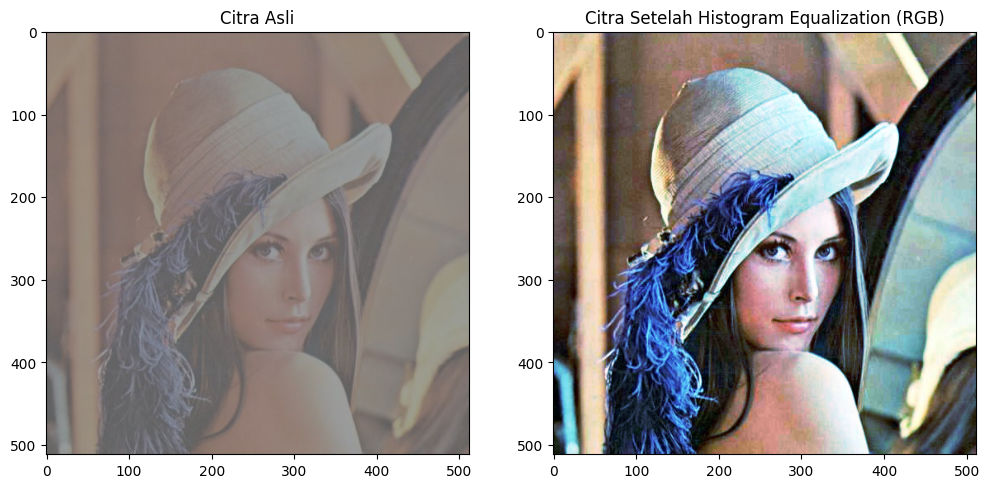

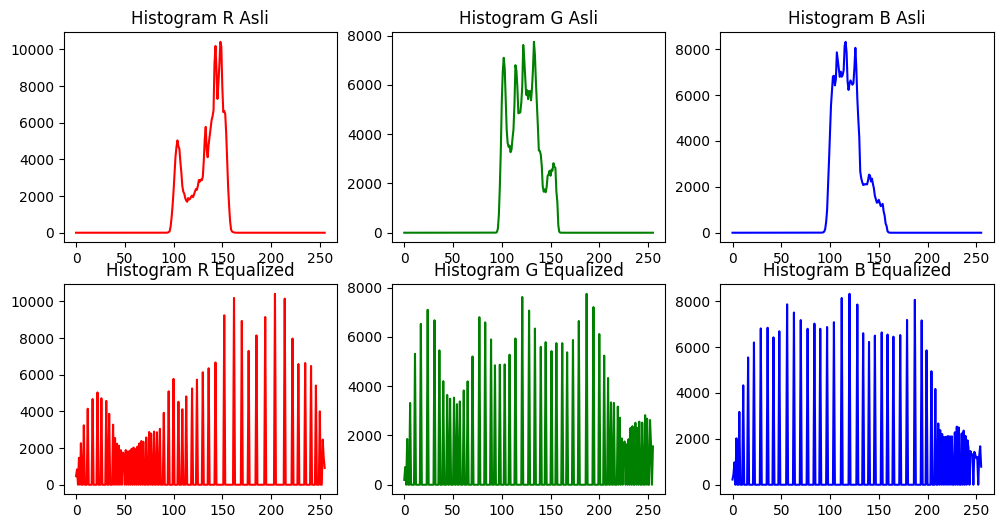

In [20]:
# 1. Buatlah histogram citra seperti output histogram equalization
img = cv.imread('/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_09/Image Jobsheet/lena_lc.jpg')
img_color = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel R, G, B
r, g, b = cv.split(img_color)

# Histogram Equalization per channel
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Gabungkan kembali citra hasil
img_eq_color = cv.merge((r_eq, g_eq, b_eq))

# -------------------------------
# Tampilkan hasil
# -------------------------------
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_color)
plt.title("Citra Asli")

plt.subplot(1,2,2)
plt.imshow(img_eq_color)
plt.title("Citra Setelah Histogram Equalization (RGB)")
plt.show()

# -------------------------------
# Plot Histogram sebelum & sesudah
# -------------------------------
colors = ('r','g','b')
plt.figure(figsize=(12,6))

for i, col in enumerate(colors):
    hist_orig = cv.calcHist([img_color],[i],None,[256],[0,256])
    hist_eq = cv.calcHist([img_eq_color],[i],None,[256],[0,256])

    plt.subplot(2,3,i+1)
    plt.plot(hist_orig, color=col)
    plt.title(f"Histogram {col.upper()} Asli")

    plt.subplot(2,3,i+4)
    plt.plot(hist_eq, color=col)
    plt.title(f"Histogram {col.upper()} Equalized")

plt.show()

/tmp/ipython-input-1968266556.py:18: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_eq_cv2.flatten(), 256, [0,256], color='red')


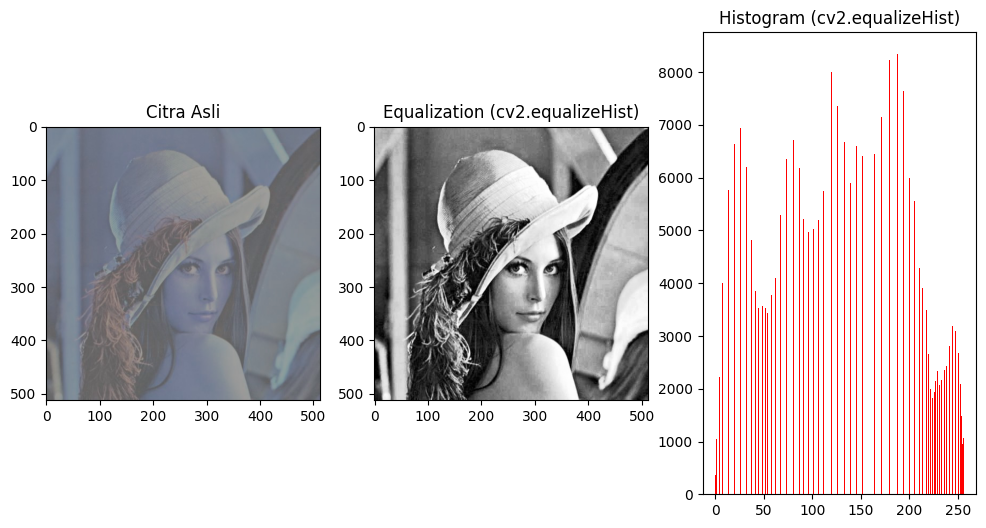

In [21]:
# 2. Histogram Equalization with OpenCV

img_gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

img_eq_cv2 = cv.equalizeHist(img_gray)

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Citra Asli")

plt.subplot(1,3,2)
plt.imshow(img_eq_cv2, cmap='gray')
plt.title("Equalization (cv2.equalizeHist)")

plt.subplot(1,3,3)
plt.hist(img_eq_cv2.flatten(), 256, [0,256], color='red')
plt.title("Histogram (cv2.equalizeHist)")

plt.show()

# PERTANYAAN PRAKTIKUM D2

In [28]:
# 1. Perbandingan Citra Lena
# a. Gunakan hasil histogram equalization pada citra lena.jpg.
print("a. Hasil equalization membuat distribusi histogram lebih merata, sehingga detail di area gelap/terang lebih jelas.")

# b. Hitung nilai PSNR antara citra asli dan citra hasil equalization.
def psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    PIXEL_MAX = 255.0
    return 20 * np.log10(PIXEL_MAX / np.sqrt(mse))

img_lena = cv.imread("/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_09/Image Jobsheet/lena.jpg", cv.IMREAD_GRAYSCALE)
img_lena_eq = cv.equalizeHist(img_lena)

psnr_value = psnr(img_lena, img_lena_eq)
print("b. PSNR antara citra asli dan equalization:", psnr_value, "dB")

# c. Apakah nilai PSNR tinggi atau rendah? Apa arti nilai tersebut terhadap kualitas visual citra? Apakah ada detail baru yang muncul setelah equalization?
print("c. Jika PSNR tinggi (>30 dB) → perbedaan tidak signifikan, kualitas visual hampir sama. Jika PSNR rendah (<20 dB) → perbedaan cukup besar.Pada kasus histogram equalization, biasanya PSNR sedikit turun, tapi detail citra meningkat.")


a. Hasil equalization membuat distribusi histogram lebih merata, sehingga detail di area gelap/terang lebih jelas.
b. PSNR antara citra asli dan equalization: 29.688975710790224 dB
c. Jika PSNR tinggi (>30 dB) → perbedaan tidak signifikan, kualitas visual hampir sama. Jika PSNR rendah (<20 dB) → perbedaan cukup besar.Pada kasus histogram equalization, biasanya PSNR sedikit turun, tapi detail citra meningkat.


a. Terapkan histogram equalization pada citra KTM lama.jpg.
b. Tampilkan citra asli, citra hasil equalization, serta histogram keduanya dalam satu layout.


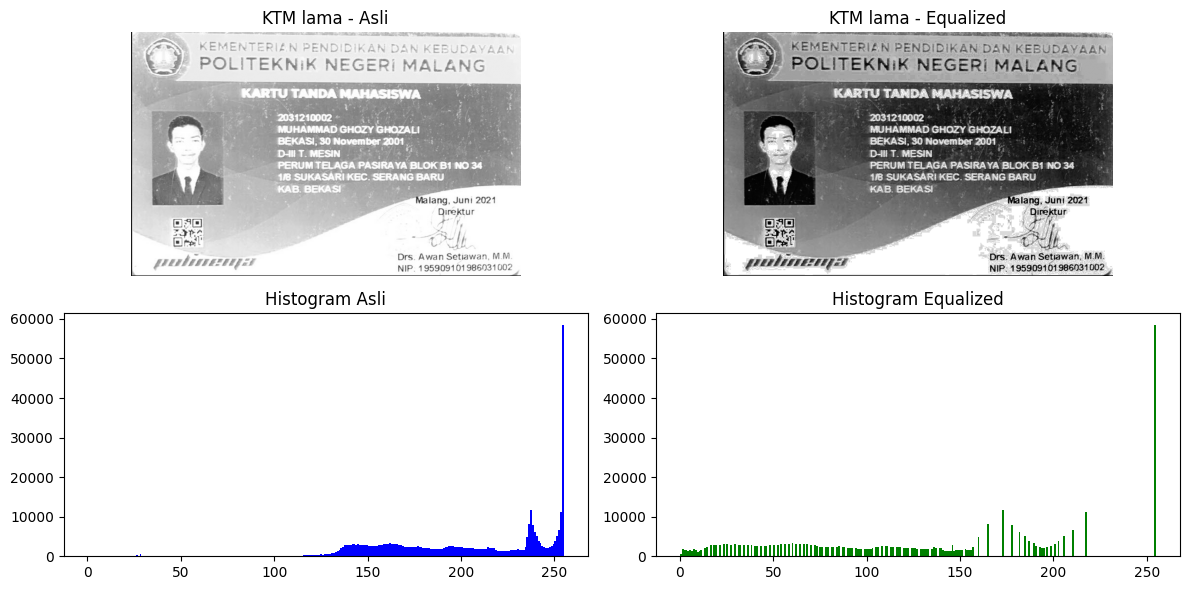

c. Bandingkan citra KTM lama.jpg sebelum dan sesudah histogram equalization
Sebelum equalization :citra tampak gelap, detail wajah, teks, dan latar belakang sulit terlihat.
Setelah equalization :citra tampak lebih kontras, wajah, teks, dan latar belakang terlihat lebih jelas.
Kualitas informasi   :perubahan ini meningkatkan kualitas informasi karena bagian yang sebelumnya tersembunyi menjadi terbaca.


In [48]:
# 2. Gunakan Citra KTM Lama.jpg
# a. Terapkan histogram equalization pada citra KTM lama.jpg.
print("a. Terapkan histogram equalization pada citra KTM lama.jpg.")
ktm = cv.imread('/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_09/Image Jobsheet/KTM lama.jpg', cv.IMREAD_GRAYSCALE)

ktm_eq = cv.equalizeHist(ktm)

plt.figure(figsize=(12,6))

# b. Tampilkan citra asli, citra hasil equalization, serta histogram keduanya dalam satu layout.
print("b. Tampilkan citra asli, citra hasil equalization, serta histogram keduanya dalam satu layout.")
plt.subplot(2,2,1)
plt.imshow(ktm, cmap='gray')
plt.title("KTM lama - Asli")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(ktm_eq, cmap='gray')
plt.title("KTM lama - Equalized")
plt.axis('off')

plt.subplot(2,2,3)
plt.hist(ktm.flatten(), bins=256, range=(0,255), color='blue')
plt.title("Histogram Asli")

plt.subplot(2,2,4)
plt.hist(ktm_eq.flatten(), bins=256, range=(0,255), color='green')
plt.title("Histogram Equalized")

plt.tight_layout()
plt.show()

# c. Bandingkan citra KTM lama.jpg sebelum dan sesudah histogram equalization
print("c. Bandingkan citra KTM lama.jpg sebelum dan sesudah histogram equalization")
print("Sebelum equalization :citra tampak gelap, detail wajah, teks, dan latar belakang sulit terlihat.")
print("Setelah equalization :citra tampak lebih kontras, wajah, teks, dan latar belakang terlihat lebih jelas.")
print("Kualitas informasi   :perubahan ini meningkatkan kualitas informasi karena bagian yang sebelumnya tersembunyi menjadi terbaca.")


# **D-3 TUGAS PRAKTIKUM DITHERING**

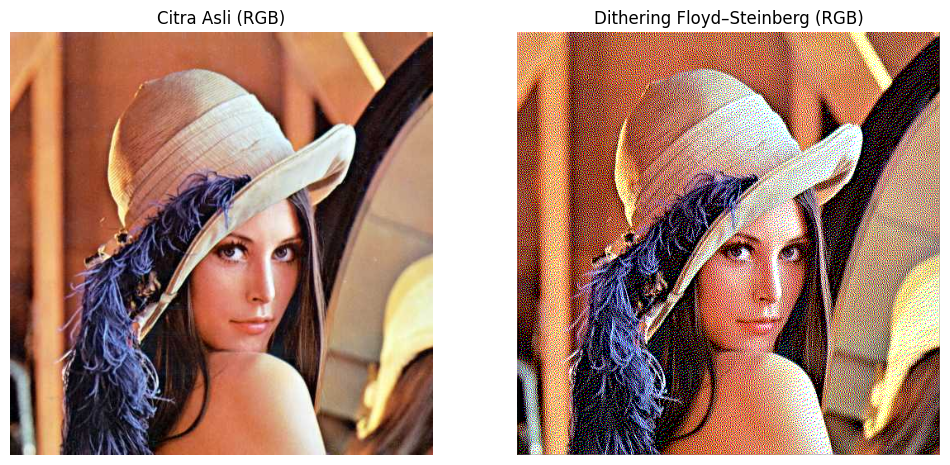

In [63]:
# 1. Lakukanlah proses dithering Floyd and Steinberg seperti output berikut (tampilan image awal, dan tampilan setelah dithering) berdasarkan flowchart di bagian bawah halaman modul ini! (Gunakan gambar lena.jpg)

img_bgr = cv.imread("/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_09/Image Jobsheet/lena.jpg")
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

img_fs = img_rgb.astype(np.float32) / 255.0
h, w, c = img_fs.shape

for y in range(h-1):
    for x in range(1, w-1):
        for ch in range(c): # Loop through color channels
            old_pixel = img_fs[y, x, ch]
            new_pixel = np.round(old_pixel)
            img_fs[y, x, ch] = new_pixel
            error = old_pixel - new_pixel

            img_fs[y, x+1, ch]     += error * 7/16
            img_fs[y+1, x-1, ch]   += error * 3/16
            img_fs[y+1, x, ch]     += error * 5/16
            img_fs[y+1, x+1, ch]   += error * 1/16

img_dither = (img_fs * 255).clip(0,255).astype(np.uint8)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.imshow(img_rgb); plt.title("Citra Asli (RGB)"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(img_dither); plt.title("Dithering Floyd–Steinberg (RGB)"); plt.axis('off')
plt.show()

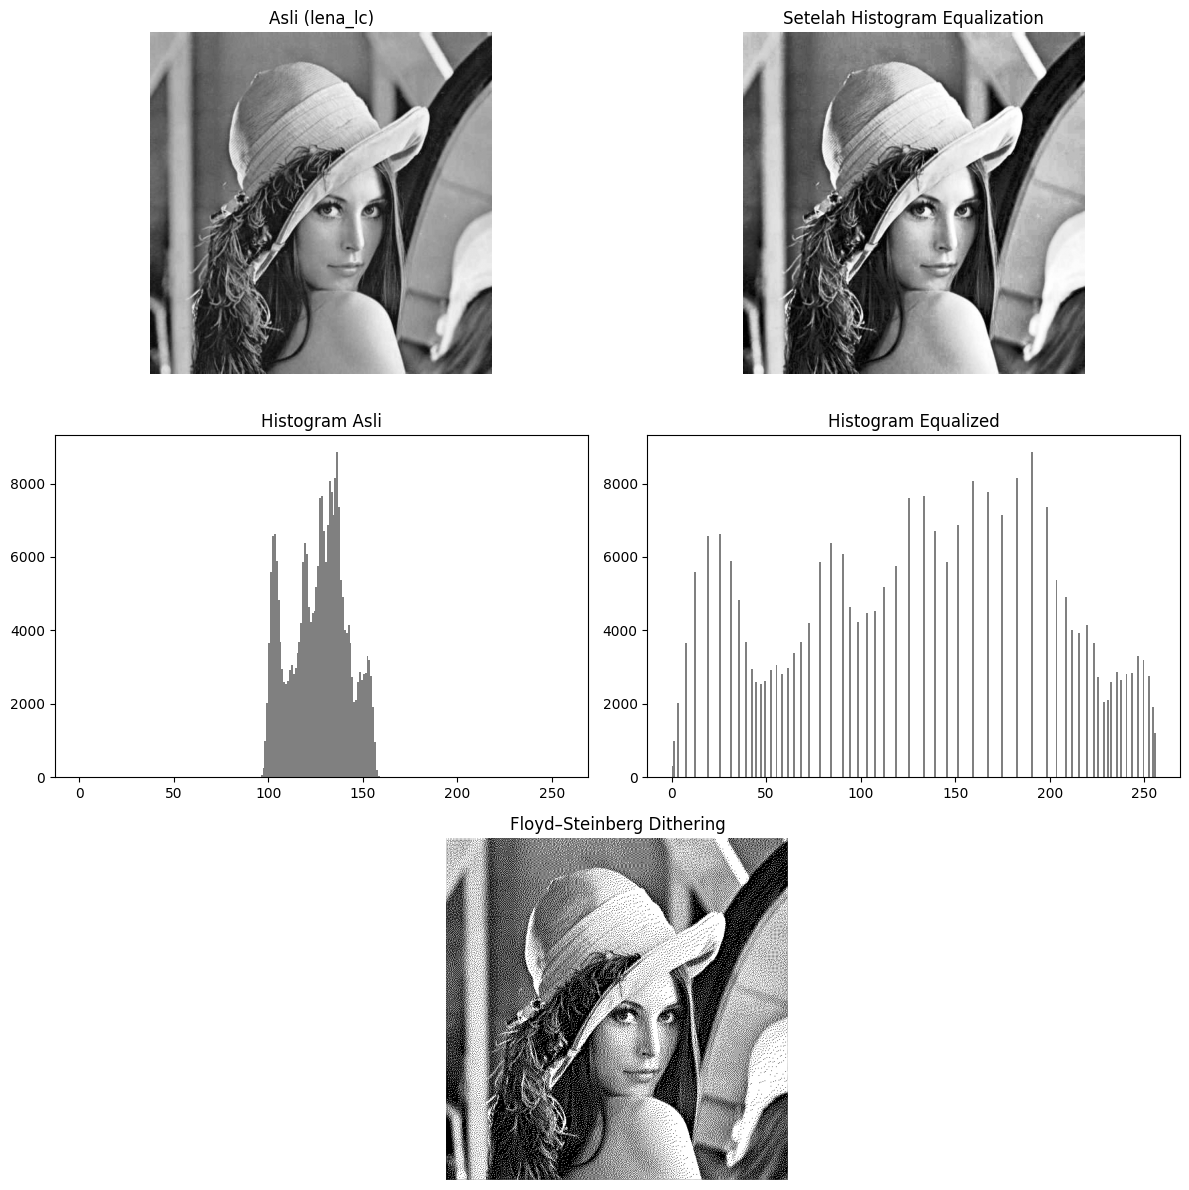

In [65]:
# 2. Menggunakan lena_lc.jpg rubah menjadi grey image, kemudian terapkan histogram equalization sehingga terjadi perbaikan sebaran warna pada citra. Setelah itu dari hasil histogram equalization implementasikan proses dithering Floyd and Steinberg
img_lc = cv.imread("/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_09/Image Jobsheet/lena_lc.jpg", cv.IMREAD_GRAYSCALE)

img_eq = cv.equalizeHist(img_lc)

def floyd_steinberg_dither_gray(img_gray):
    img = img_gray.astype(np.float32)
    h, w = img.shape

    for y in range(h-1):
        for x in range(1, w-1):
            old_pixel = img[y, x]
            new_pixel = 0 if old_pixel < 128 else 255
            img[y, x] = new_pixel
            error = old_pixel - new_pixel

            img[y, x+1]   = np.clip(img[y, x+1]   + error * 7/16, 0, 255)
            img[y+1, x-1] = np.clip(img[y+1, x-1] + error * 3/16, 0, 255)
            img[y+1, x]   = np.clip(img[y+1, x]   + error * 5/16, 0, 255)
            img[y+1, x+1] = np.clip(img[y+1, x+1] + error * 1/16, 0, 255)

    return img.astype(np.uint8)

img_dither = floyd_steinberg_dither_gray(img_eq)

plt.figure(figsize=(12,12))

plt.subplot(3,2,1); plt.imshow(img_lc, cmap='gray'); plt.title("Asli (lena_lc)"); plt.axis('off')
plt.subplot(3,2,2); plt.imshow(img_eq, cmap='gray'); plt.title("Setelah Histogram Equalization"); plt.axis('off')

plt.subplot(3,2,3); plt.hist(img_lc.flatten(), bins=256, range=(0,256), color='gray'); plt.title("Histogram Asli")
plt.subplot(3,2,4); plt.hist(img_eq.flatten(), bins=256, range=(0,256), color='gray'); plt.title("Histogram Equalized")

plt.subplot(3,1,3); plt.imshow(img_dither, cmap='gray'); plt.title("Floyd–Steinberg Dithering"); plt.axis('off')

plt.tight_layout()
plt.show()